# Лабораторная работа № 11 (6)
## Глубокие нейронные сети: классификация текстов и изображений

**Вариант 10**

Датасеты:
- **Тексты:** `scientific_articles.csv` — многоклассовая классификация научных аннотаций (ai / chemistry / energy / materials)
- **Изображения:** `japanese_textiles` + `sri_lankan_textiles` — бинарная классификация текстиля по стране происхождения

Шаги:
1. Разбиение данных на обучающую / валидационную / тестовую выборки (70 / 15 / 15)
2. Глубокая нейронная сеть с рекуррентными слоями (LSTM) для текстов
3. Глубокая нейронная сеть с свёрточными слоями (CNN) для изображений
4. Оценка метрик (accuracy, precision, recall, F1, ROC-AUC)
5. Перенос обучения: BERT (тексты), VGG16 (изображения)
6. Сравнение всех моделей

In [3]:
import os
import warnings

os.environ['KERAS_BACKEND'] = 'torch'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix,
)

SEED = 42
keras.utils.set_random_seed(SEED)
sns.set_theme(style='whitegrid')

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
    print('GPU CUDA активен')
else:
    print('Используется CPU')

print(f'Keras {keras.__version__}, Torch {torch.__version__}')

Используется CPU
Keras 3.14.1, Torch 2.11.0+cu130


## Часть 1: Классификация текстов (LSTM)
### 1.1 Загрузка и подготовка данных

Используется тот же набор и та же слабая разметка, что в лабораторной работе 6:
- 30 000 строк из `scientific_articles.csv`
- Четыре тематических класса: **ai**, **chemistry**, **energy**, **materials**
- По 350 документов на класс → 1 400 итого

In [6]:
TEXT_PATH = '../../data/scientific_articles.csv'
MAX_ROWS   = 30_000
CHUNK_SIZE = 5_000
SAMPLE_PER_CLASS = 350

KEYWORDS = {
    'energy':    {'battery','energy','electrode','electrolyte','capacitor',
                  'photovoltaic','solar','supercapacitor','fuel cell'},
    'chemistry': {'chemical','reaction','synthesis','catalyst','compound',
                  'molecule','polymerization','spectroscopy','chromatography'},
    'materials': {'material','carbon','alloy','composite','ceramic',
                  'nanotube','film','membrane','coating','nanoparticle'},
    'ai':        {'algorithm','learning','neural','classification','prediction',
                  'optimization','machine learning','deep learning','computer vision'},
}

def assign_weak_label(text):
    t = text.lower()
    scores = {lbl: sum(kw in t for kw in kws) for lbl, kws in KEYWORDS.items()}
    pos = {l: s for l, s in scores.items() if s > 0}
    if len(pos) != 1:
        return None
    return next(iter(pos))

frames = []
rows_loaded = 0
for chunk in pd.read_csv(TEXT_PATH, usecols=['title', 'abstract'], chunksize=CHUNK_SIZE):
    chunk = chunk.dropna(subset=['title', 'abstract']).copy()
    frames.append(chunk)
    rows_loaded += len(chunk)
    if rows_loaded >= MAX_ROWS:
        break

df_raw = pd.concat(frames, ignore_index=True).iloc[:MAX_ROWS].copy()
df_raw['text'] = (df_raw['title'].str.strip() + ' ' + df_raw['abstract'].str.strip())
df_raw['label'] = df_raw['text'].map(assign_weak_label)

df_labeled = df_raw.dropna(subset=['label'])
min_class = df_labeled['label'].value_counts().min()
n_per_class = min(SAMPLE_PER_CLASS, min_class)

df = (
    df_labeled.groupby('label', group_keys=False)
    .apply(lambda g: g.sample(n_per_class, random_state=SEED))
    .reset_index(drop=True)
)

CLASSES_TEXT = sorted(df['label'].unique())
label2id = {l: i for i, l in enumerate(CLASSES_TEXT)}
df['label_id'] = df['label'].map(label2id)

print(f'Итоговый датасет: {len(df)} документов')
print(df['label'].value_counts())

Итоговый датасет: 1400 документов
label
ai           350
chemistry    350
energy       350
materials    350
Name: count, dtype: int64


### 1.2 Разбиение 70 / 15 / 15

Train: 980, Val: 210, Test: 210


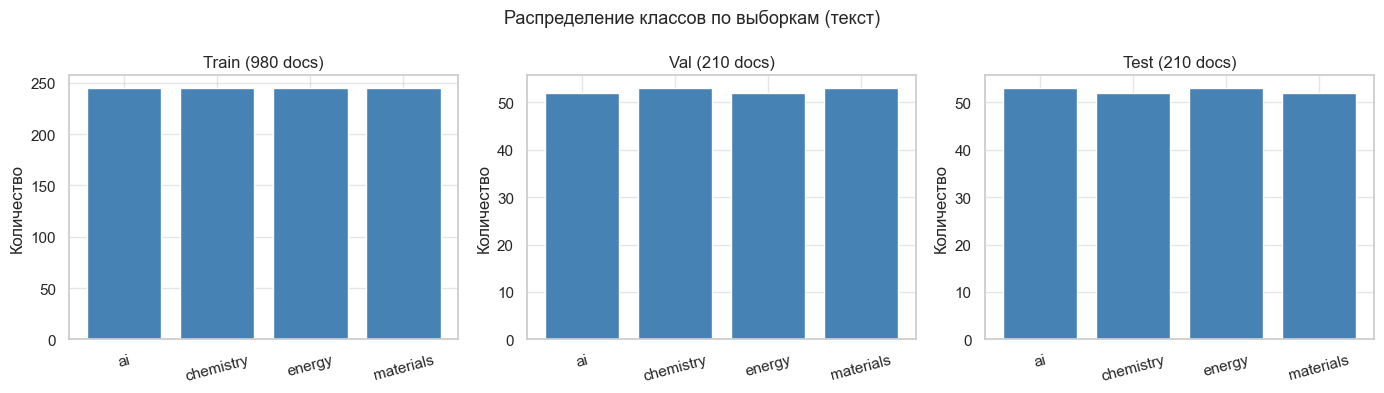

In [7]:
X_text = df['text'].values
y_text = df['label_id'].values

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_text, y_text, test_size=0.30, random_state=SEED, stratify=y_text
)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp
)

print(f'Train: {len(X_tr)}, Val: {len(X_val)}, Test: {len(X_te)}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, y, title in zip(axes, [y_tr, y_val, y_te], ['Train', 'Val', 'Test']):
    counts = pd.Series(y).value_counts().sort_index()
    ax.bar([CLASSES_TEXT[i] for i in counts.index], counts.values, color='steelblue')
    ax.set_title(f'{title} ({len(y)} docs)')
    ax.set_ylabel('Количество')
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Распределение классов по выборкам (текст)', fontsize=13)
plt.tight_layout()
plt.show()

### 1.3 Предобработка: токенизация и паддинг

В Keras 3.x вместо убранного `keras.preprocessing.text` используется слой `keras.layers.TextVectorization`:
- словарь: 10 000 наиболее частых слов (включая служебный токен `[UNK]`);
- максимальная длина: 200 токенов (обрезка и паддинг справа — стандартное поведение слоя).

In [8]:
from keras.layers import TextVectorization

VOCAB_SIZE = 10_000
MAX_LEN    = 200
N_CLASSES  = len(CLASSES_TEXT)

vectorizer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN,
)
vectorizer.adapt(X_tr.tolist())

def encode(texts):
    return vectorizer(list(texts)).numpy()

X_tr_enc  = encode(X_tr)
X_val_enc = encode(X_val)
X_te_enc  = encode(X_te)

y_tr_cat  = keras.utils.to_categorical(y_tr,  N_CLASSES)
y_val_cat = keras.utils.to_categorical(y_val, N_CLASSES)
y_te_cat  = keras.utils.to_categorical(y_te,  N_CLASSES)

print(f'X_tr_enc shape: {X_tr_enc.shape}')
print(f'Пример (первые 10 индексов первого документа): {X_tr_enc[0, :10]}')

X_tr_enc shape: (980, 200)
Пример (первые 10 индексов первого документа): [   1  252 8369    5    1    1    1    1  866 1202]


2026-05-12 00:00:48.016030: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


### 1.4 Архитектура LSTM

| Слой | Параметры | Назначение |
|------|-----------|------------|
| Embedding | vocab=10k, dim=64 | Векторное представление слов |
| SpatialDropout1D | p=0.20 | Регуляризация эмбеддингов |
| LSTM | units=128, dropout=0.20 | Извлечение контекстных зависимостей |
| Dense | 64, ReLU | Промежуточная проекция |
| Dropout | p=0.30 | Регуляризация |
| Dense | 4, Softmax | Выходной слой классификации |

**Функция потерь:** categorical crossentropy (многоклассовая задача)  
**Оптимизатор:** Adam (lr=1e-3)  
**Гиперпараметры:** batch=64, epochs=15, EarlyStopping(patience=3)

In [9]:
from keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, InputLayer
from keras.models import Sequential
from keras.callbacks import EarlyStopping

def build_lstm():
    model = Sequential([
        InputLayer(shape=(MAX_LEN,), dtype='float32'),
        Embedding(VOCAB_SIZE, 64),
        SpatialDropout1D(0.20),
        LSTM(128, dropout=0.20, recurrent_dropout=0.20),
        Dense(64, activation='relu'),
        Dropout(0.30),
        Dense(N_CLASSES, activation='softmax'),
    ])
    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        metrics=['accuracy'],
    )
    return model

lstm_model = build_lstm()
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 747,332 (2.85 MB)

 Trainable params: 747,332 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

lstm_history = lstm_model.fit(
    X_tr_enc, y_tr_cat,
    batch_size=64,
    epochs=15,
    validation_data=(X_val_enc, y_val_cat),
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 465ms/step - accuracy: 0.2531 - loss: 1.3873 - val_accuracy: 0.2238 - val_loss: 1.3843
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 403ms/step - accuracy: 0.2959 - loss: 1.3811 - val_accuracy: 0.3095 - val_loss: 1.3802
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 444ms/step - accuracy: 0.2908 - loss: 1.3733 - val_accuracy: 0.3238 - val_loss: 1.3721
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 412ms/step - accuracy: 0.3153 - loss: 1.3719 - val_accuracy: 0.3143 - val_loss: 1.3704
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 422ms/step - accuracy: 0.3480 - loss: 1.3446 - val_accuracy: 0.3095 - val_loss: 1.3586
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 405ms/step - accuracy: 0.3439 - loss: 1.3168 - val_accuracy: 0.4095 - val_loss: 1.5524
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 407ms/step - accuracy: 0.4306 - loss: 1.2277 - val_accuracy: 0.4000 - val_loss: 1.2556
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 442ms/step - accuracy: 0.4418 - loss: 1.1533 - val_accuracy: 0.

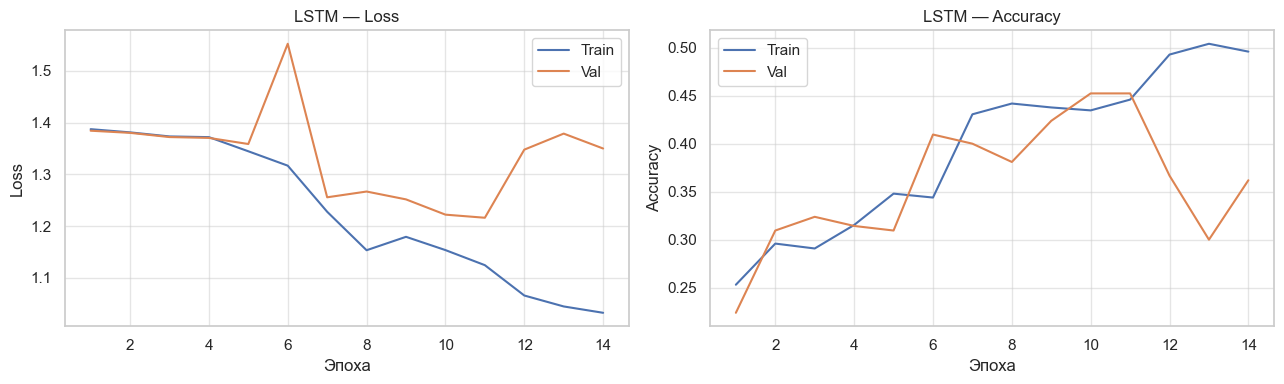

In [11]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history.history['loss']) + 1)

    axes[0].plot(epochs, history.history['loss'],     label='Train')
    axes[0].plot(epochs, history.history['val_loss'], label='Val')
    axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].legend()

    axes[1].plot(epochs, history.history['accuracy'],     label='Train')
    axes[1].plot(epochs, history.history['val_accuracy'], label='Val')
    axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(lstm_history, 'LSTM')

### 1.5 Оценка LSTM на тестовой выборке

=== LSTM ===
Accuracy:  0.4667
Precision: 0.4244
Recall:    0.4664
F1 macro:  0.3872
ROC-AUC:   0.7028

              precision    recall  f1-score   support

          ai       0.84      0.30      0.44        53
   chemistry       0.45      0.88      0.59        52
      energy       0.41      0.68      0.51        53
   materials       0.00      0.00      0.00        52

    accuracy                           0.47       210
   macro avg       0.42      0.47      0.39       210
weighted avg       0.43      0.47      0.39       210



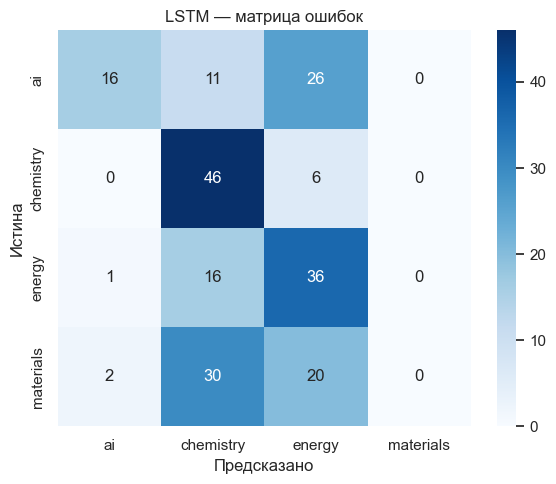

In [12]:
def evaluate_clf(model, X_enc, y_true, classes, model_name='Model'):
    proba = model.predict(X_enc, verbose=0)
    y_pred = np.argmax(proba, axis=1)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(y_true, proba, multi_class='ovr', average='macro')
    except Exception:
        auc = float('nan')

    print(f'=== {model_name} ===')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1 macro:  {f1:.4f}')
    print(f'ROC-AUC:   {auc:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(pd.DataFrame(cm, index=classes, columns=classes),
                annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{model_name} — матрица ошибок')
    ax.set_xlabel('Предсказано'); ax.set_ylabel('Истина')
    plt.tight_layout(); plt.show()

    return dict(model=model_name, accuracy=acc, precision=prec,
                recall=rec, f1=f1, roc_auc=auc)

text_results = []
lstm_metrics = evaluate_clf(lstm_model, X_te_enc, y_te, CLASSES_TEXT, 'LSTM')
text_results.append(lstm_metrics)

### 1.6 Наивная модель (тексты)

Предсказывает наиболее частый класс из обучающей выборки для всех объектов.

In [13]:
most_frequent_text = int(np.bincount(y_tr).argmax())
y_naive_text = np.full(len(y_te), most_frequent_text)

naive_text_metrics = dict(
    model='Наивная (текст)',
    accuracy  = accuracy_score(y_te, y_naive_text),
    precision = precision_score(y_te, y_naive_text, average='macro', zero_division=0),
    recall    = recall_score(y_te, y_naive_text, average='macro', zero_division=0),
    f1        = f1_score(y_te, y_naive_text, average='macro', zero_division=0),
    roc_auc   = float('nan'),
)
print(f'Наивная модель (класс «{CLASSES_TEXT[most_frequent_text]}»):')
for k, v in naive_text_metrics.items():
    if k != 'model':
        print(f'  {k}: {v:.4f}')
text_results.insert(0, naive_text_metrics)

Наивная модель (класс «ai»):
  accuracy: 0.2524
  precision: 0.0631
  recall: 0.2500
  f1: 0.1008
  roc_auc: nan


### 1.7 Результат лабораторной работы 6 (LinearSVC + TF-IDF)

Лучшая конфигурация из ЛР-6: **LinearSVC + TF-IDF + лемматизация**, результат на тестовой выборке (25 % = 350 документов):

| Метрика | Значение |
|---------|----------|
| Accuracy | 0.8943 |
| Macro F1 | 0.8939 |
| Precision (macro) | 0.8975 |
| Recall (macro) | 0.8943 |

In [14]:
lab6_metrics = dict(
    model='LinearSVC (ЛР-6)',
    accuracy=0.8943,
    precision=0.8975,
    recall=0.8943,
    f1=0.8939,
    roc_auc=float('nan'),
)
text_results.insert(1, lab6_metrics)
print('Базовый результат ЛР-6 добавлен в таблицу.')

Базовый результат ЛР-6 добавлен в таблицу.


### 1.8 Перенос обучения: BERT

Используется `keras_hub.models.BertClassifier` (пресет `bert_tiny_en_uncased`, ~4.4M параметров) — более лёгкая версия BERT-base, пригодная для обучения на CPU.

Стратегия:
- Загрузка предобученных весов (обучение на Wikipedia + BooksCorpus)
- **Заморозка** слоёв Transformer-блоков (`backbone.trainable = False`)
- Обучение только классификационной головы (Dense 4, Softmax)

> **Примечание:** на CPU одна эпоха занимает ~10–20 мин. При наличии GPU время существенно сокращается.

In [15]:
import keras_hub as keras_nlp

bert_classifier = keras_nlp.models.BertClassifier.from_preset(
    'bert_tiny_en_uncased',
    num_classes=N_CLASSES,
)

# Заморозка весов базовой модели — обучаем только классификационную голову
bert_classifier.backbone.trainable = False

bert_classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

trainable = sum(np.prod(w.shape) for w in bert_classifier.trainable_weights)
total     = sum(np.prod(w.shape) for w in bert_classifier.weights)
print(f'Обучаемых параметров: {trainable:,} / {total:,}')

100%|██████████| 454/454 [00:00<00:00, 1.50MB/s]


100%|██████████| 16.8M/16.8M [00:02<00:00, 6.60MB/s]


100%|██████████| 761/761 [00:00<00:00, 2.28MB/s]


100%|██████████| 226k/226k [00:00<00:00, 641kB/s]

Обучаемых параметров: 516 / 4,386,436


Epoch 1/3
31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 709ms/step - accuracy: 0.2898 - loss: 1.3788 - val_accuracy: 0.3952 - val_loss: 1.3561
Epoch 2/3
31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 704ms/step - accuracy: 0.4245 - loss: 1.3363 - val_accuracy: 0.4571 - val_loss: 1.3252
Epoch 3/3
31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 715ms/step - accuracy: 0.4602 - loss: 1.3098 - val_accuracy: 0.4381 - val_loss: 1.3006


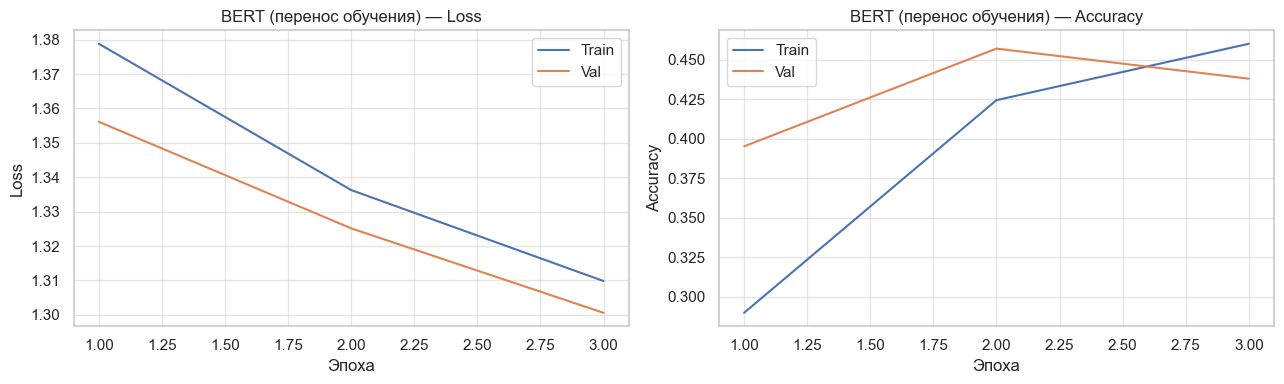

In [16]:
# BERT принимает сырые строки, предобработка выполняется внутри модели
X_tr_bert  = X_tr.tolist()
X_val_bert = X_val.tolist()
X_te_bert  = X_te.tolist()

bert_history = bert_classifier.fit(
    x=X_tr_bert,
    y=y_tr,
    batch_size=32,
    epochs=3,
    validation_data=(X_val_bert, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
    verbose=1,
)

plot_history(bert_history, 'BERT (перенос обучения)')

=== BERT (перенос обучения) ===
Accuracy:  0.5000
Precision: 0.5130
Recall:    0.4985
F1 macro:  0.4675
ROC-AUC:   0.7726

              precision    recall  f1-score   support

          ai       0.44      0.91      0.59        53
   chemistry       0.68      0.52      0.59        52
      energy       0.54      0.42      0.47        53
   materials       0.40      0.15      0.22        52

    accuracy                           0.50       210
   macro avg       0.51      0.50      0.47       210
weighted avg       0.51      0.50      0.47       210



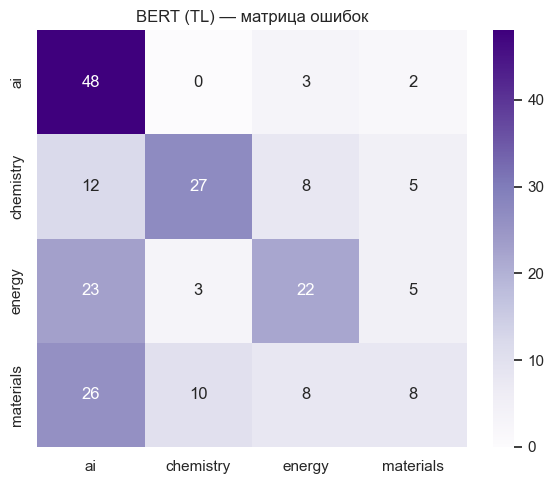

In [17]:
import tensorflow as tf

bert_logits = bert_classifier.predict(X_te_bert, verbose=0)
bert_proba  = tf.nn.softmax(bert_logits).numpy()
bert_pred   = np.argmax(bert_proba, axis=1)

acc  = accuracy_score(y_te, bert_pred)
prec = precision_score(y_te, bert_pred, average='macro', zero_division=0)
rec  = recall_score(y_te, bert_pred, average='macro', zero_division=0)
f1   = f1_score(y_te, bert_pred, average='macro', zero_division=0)
try:
    auc = roc_auc_score(y_te, bert_proba, multi_class='ovr', average='macro')
except Exception:
    auc = float('nan')

print('=== BERT (перенос обучения) ===')
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1 macro:  {f1:.4f}')
print(f'ROC-AUC:   {auc:.4f}')
print()
print(classification_report(y_te, bert_pred, target_names=CLASSES_TEXT))

cm_bert = confusion_matrix(y_te, bert_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pd.DataFrame(cm_bert, index=CLASSES_TEXT, columns=CLASSES_TEXT),
            annot=True, fmt='d', cmap='Purples', ax=ax)
ax.set_title('BERT (TL) — матрица ошибок')
plt.tight_layout(); plt.show()

bert_metrics = dict(model='BERT (TL)', accuracy=acc, precision=prec,
                    recall=rec, f1=f1, roc_auc=auc)
text_results.append(bert_metrics)

## Часть 2: Классификация изображений (CNN)
### 2.1 Загрузка и подготовка изображений

Датасет: 1 000 изображений (500 японский текстиль, 500 шри-ланкийский). Разбиение: 70 / 15 / 15.

In [18]:
META_PATH = '../../data/metadata.csv'
DATA_DIR  = '../../data'
IMG_SIZE_CNN = (128, 128)   # для CNN
IMG_SIZE_VGG = (224, 224)   # для VGG16

meta = pd.read_csv(META_PATH)
meta['path'] = DATA_DIR + '/' + meta['filename']
meta['label'] = (meta['country'] == 'sri_lanka').astype(int)  # 0=japan, 1=sri_lanka
CLASSES_IMG = ['japan', 'sri_lanka']
N_CLASSES_IMG = 2

print(f'Всего изображений: {len(meta)}')
print(meta['country'].value_counts())

Всего изображений: 2000
country
japan        1000
sri_lanka    1000
Name: count, dtype: int64


In [19]:
meta_tr, meta_tmp = train_test_split(
    meta, test_size=0.30, random_state=SEED, stratify=meta['label']
)
meta_val, meta_te = train_test_split(
    meta_tmp, test_size=0.50, random_state=SEED, stratify=meta_tmp['label']
)

print(f'Train: {len(meta_tr)}, Val: {len(meta_val)}, Test: {len(meta_te)}')
print('Train classes:', dict(meta_tr['country'].value_counts()))
print('Val   classes:', dict(meta_val['country'].value_counts()))
print('Test  classes:', dict(meta_te['country'].value_counts()))

Train: 1400, Val: 300, Test: 300
Train classes: {'japan': np.int64(700), 'sri_lanka': np.int64(700)}
Val   classes: {'sri_lanka': np.int64(150), 'japan': np.int64(150)}
Test  classes: {'sri_lanka': np.int64(150), 'japan': np.int64(150)}


In [20]:
def load_images_np(meta_df, size):
    images = []
    for path in meta_df['path']:
        img = keras.utils.load_img(path, target_size=size)
        images.append(keras.utils.img_to_array(img) / 255.0)
    return np.array(images, dtype=np.float32)

print('Загрузка изображений 128×128 ...')
X_tr_img  = load_images_np(meta_tr,  IMG_SIZE_CNN)
X_val_img = load_images_np(meta_val, IMG_SIZE_CNN)
X_te_img  = load_images_np(meta_te,  IMG_SIZE_CNN)

y_tr_img  = keras.utils.to_categorical(meta_tr['label'].values,  N_CLASSES_IMG)
y_val_img = keras.utils.to_categorical(meta_val['label'].values, N_CLASSES_IMG)
y_te_img  = keras.utils.to_categorical(meta_te['label'].values,  N_CLASSES_IMG)
y_te_img_raw = meta_te['label'].values

print(f'X_tr_img: {X_tr_img.shape}, dtype={X_tr_img.dtype}')

Загрузка изображений 128×128 ...
X_tr_img: (1400, 128, 128, 3), dtype=float32


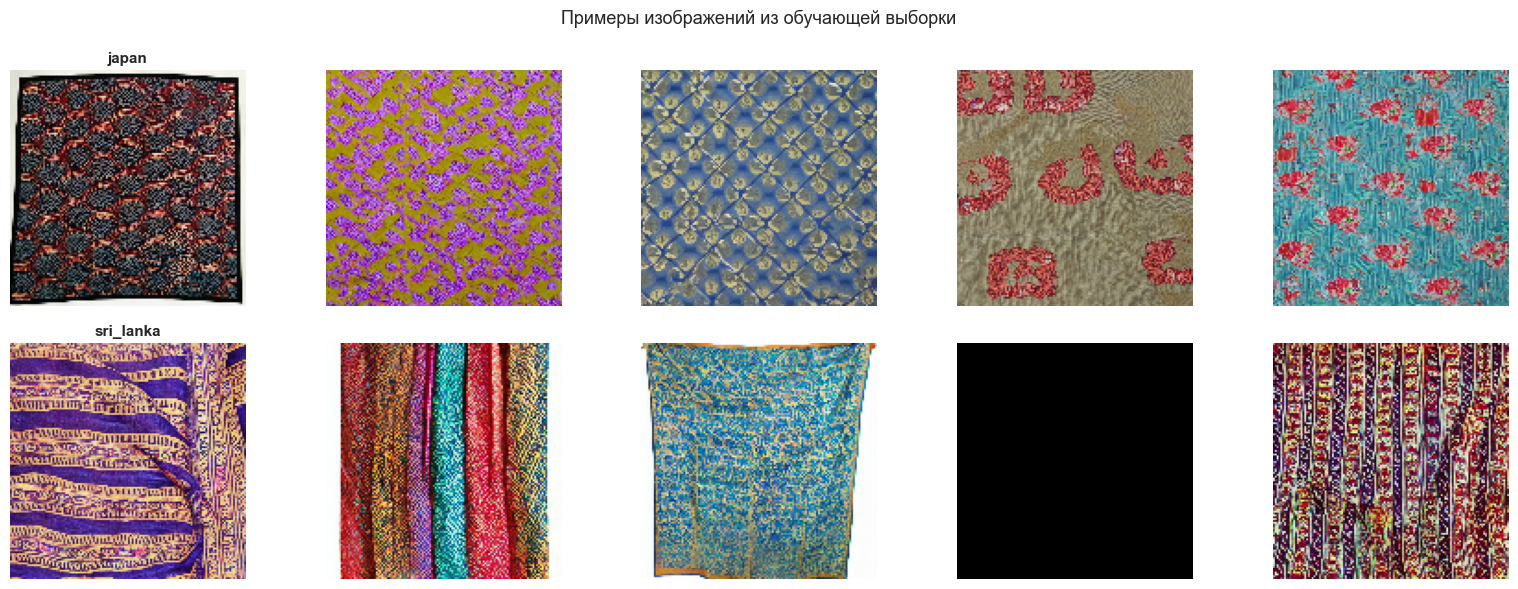

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for row, (country, label_id) in enumerate([('japan', 0), ('sri_lanka', 1)]):
    idx = meta_tr[meta_tr['label'] == label_id].index[:5]
    pos = [list(meta_tr.index).index(i) for i in idx]
    for col, p in enumerate(pos):
        axes[row, col].imshow(X_tr_img[p])
        axes[row, col].axis('off')
    axes[row, 0].set_title(country, fontsize=11, fontweight='bold')
plt.suptitle('Примеры изображений из обучающей выборки', fontsize=13)
plt.tight_layout()
plt.show()

### 2.2 Архитектура CNN

Трёхблочная свёрточная сеть:

| Блок | Слои | Выход |
|------|------|-------|
| Вход | — | 128×128×3 |
| Блок 1 | Conv2D(32, 3×3, same, ReLU) + MaxPool(2×2) + Dropout(0.25) | 64×64×32 |
| Блок 2 | Conv2D(64, 3×3, same, ReLU) + MaxPool(2×2) + Dropout(0.25) | 32×32×64 |
| Блок 3 | Conv2D(128, 3×3, same, ReLU) + MaxPool(2×2) + Dropout(0.25) | 16×16×128 |
| Голова | Flatten → Dense(256, ReLU) → Dropout(0.50) → Dense(2, Softmax) | — |

**Функция потерь:** binary crossentropy  
**Оптимизатор:** Adam (lr=1e-3)  
**Гиперпараметры:** batch=32, epochs=25, EarlyStopping(patience=4)

In [22]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, BatchNormalization

def build_cnn(input_shape=(128, 128, 3), n_classes=2):
    model = Sequential([
        InputLayer(shape=input_shape),

        # Блок 1
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Блок 2
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Блок 3
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Классификационная голова
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.50),
        Dense(n_classes, activation='softmax'),
    ])
    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        metrics=['accuracy'],
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,483,522 (32.36 MB)

 Trainable params: 8,483,074 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.7214 - loss: 4.1998 - val_accuracy: 0.5000 - val_loss: 8.0590
Epoch 2/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 904ms/step - accuracy: 0.7836 - loss: 3.4396 - val_accuracy: 0.5000 - val_loss: 8.0590
Epoch 3/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 36s 808ms/step - accuracy: 0.8200 - loss: 2.8509 - val_accuracy: 0.5000 - val_loss: 8.0590
Epoch 4/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 36s 832ms/step - accuracy: 0.8386 - loss: 2.4597 - val_accuracy: 0.5000 - val_loss: 8.0214
Epoch 5/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 916ms/step - accuracy: 0.8621 - loss: 2.1624 - val_accuracy: 0.5033 - val_loss: 8.0053
Epoch 6/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 872ms/step - accuracy: 0.8821 - loss: 1.8424 - val_accuracy: 0.4767 - val_loss: 8.0476
Epoch 7/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 35s 792ms/step - accuracy: 0.8679 - loss: 2.0927 - val_accuracy: 0.7233 - val_loss: 3.8398
Epoch 8/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 38s 855ms/step - accuracy: 0.9036 - loss: 1.5388 - val_accurac

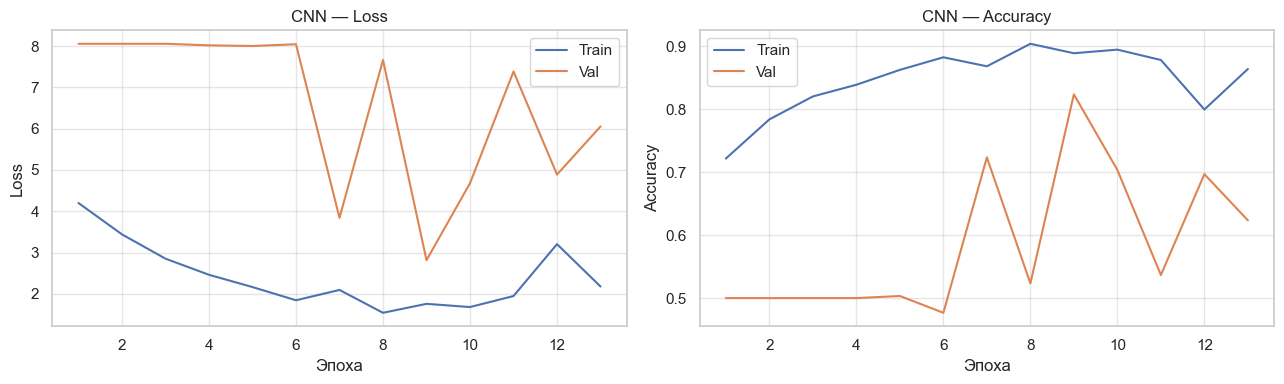

In [23]:
cnn_history = cnn_model.fit(
    X_tr_img, y_tr_img,
    batch_size=32,
    epochs=25,
    validation_data=(X_val_img, y_val_img),
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)],
    verbose=1,
)

plot_history(cnn_history, 'CNN')

### 2.3 Оценка CNN на тестовой выборке

=== CNN ===
Accuracy:  0.8100
Precision: 0.8407
Recall:    0.8100
F1 macro:  0.8056
ROC-AUC:   0.8632

              precision    recall  f1-score   support

       japan       0.74      0.96      0.83       150
   sri_lanka       0.94      0.66      0.78       150

    accuracy                           0.81       300
   macro avg       0.84      0.81      0.81       300
weighted avg       0.84      0.81      0.81       300



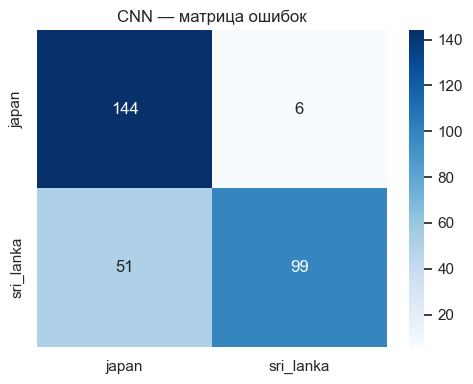

In [24]:
def evaluate_img_clf(proba, y_true_raw, classes, model_name='Model'):
    y_pred = np.argmax(proba, axis=1)

    acc  = accuracy_score(y_true_raw, y_pred)
    prec = precision_score(y_true_raw, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true_raw, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true_raw, y_pred, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(y_true_raw, proba[:, 1])
    except Exception:
        auc = float('nan')

    print(f'=== {model_name} ===')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1 macro:  {f1:.4f}')
    print(f'ROC-AUC:   {auc:.4f}')
    print()
    print(classification_report(y_true_raw, y_pred, target_names=classes))

    cm = confusion_matrix(y_true_raw, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(pd.DataFrame(cm, index=classes, columns=classes),
                annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{model_name} — матрица ошибок')
    plt.tight_layout(); plt.show()

    return dict(model=model_name, accuracy=acc, precision=prec,
                recall=rec, f1=f1, roc_auc=auc)

img_results = []

cnn_proba = cnn_model.predict(X_te_img, verbose=0)
cnn_metrics = evaluate_img_clf(cnn_proba, y_te_img_raw, CLASSES_IMG, 'CNN')
img_results.append(cnn_metrics)

### 2.4 Наивная модель (изображения)

In [25]:
most_frequent_img = int(np.bincount(meta_tr['label'].values).argmax())
y_naive_img = np.full(len(y_te_img_raw), most_frequent_img)

naive_img_metrics = dict(
    model='Наивная (изображения)',
    accuracy  = accuracy_score(y_te_img_raw, y_naive_img),
    precision = precision_score(y_te_img_raw, y_naive_img, average='macro', zero_division=0),
    recall    = recall_score(y_te_img_raw, y_naive_img, average='macro', zero_division=0),
    f1        = f1_score(y_te_img_raw, y_naive_img, average='macro', zero_division=0),
    roc_auc   = float('nan'),
)
print(f'Наивная модель (класс «{CLASSES_IMG[most_frequent_img]}»):')
for k, v in naive_img_metrics.items():
    if k != 'model':
        print(f'  {k}: {v:.4f}')

img_results.insert(0, naive_img_metrics)

Наивная модель (класс «japan»):
  accuracy: 0.5000
  precision: 0.2500
  recall: 0.5000
  f1: 0.3333
  roc_auc: nan


### 2.5 Результат лабораторной работы 7 (Random Forest + HOG/LBP/Haralick)

Лучшая модель из ЛР-7 на полном датасете 1 000 изображений (5-fold CV):

| Метрика | Значение |
|---------|----------|
| Accuracy | 0.940 |
| Weighted F1 | 0.940 |

In [26]:
lab7_metrics = dict(
    model='Random Forest (ЛР-7)',
    accuracy=0.940,
    precision=0.940,
    recall=0.940,
    f1=0.940,
    roc_auc=float('nan'),
)
img_results.insert(1, lab7_metrics)
print('Базовый результат ЛР-7 добавлен в таблицу.')

Базовый результат ЛР-7 добавлен в таблицу.


### 2.6 Перенос обучения: VGG16

Используется предобученная сеть VGG16 (веса ImageNet):
- Входной размер: 224×224×3
- Базовая модель **заморожена** (`vgg16.trainable = False`)
- Добавляется голова: GlobalAveragePooling2D → Dropout(0.50) → Dense(2, Softmax)

**Оптимизатор:** Adam (lr=1e-4, уменьшенная скорость для TL)  
**Параметры:** batch=32, epochs=15

In [27]:
print('Загрузка изображений 224×224 для VGG16 ...')
X_tr_vgg  = load_images_np(meta_tr,  IMG_SIZE_VGG)
X_val_vgg = load_images_np(meta_val, IMG_SIZE_VGG)
X_te_vgg  = load_images_np(meta_te,  IMG_SIZE_VGG)
print(f'X_tr_vgg: {X_tr_vgg.shape}')

Загрузка изображений 224×224 для VGG16 ...
X_tr_vgg: (1400, 224, 224, 3)


In [2]:
from keras.applications import VGG16
from keras.layers import GlobalAveragePooling2D
from keras import Model, Input

# Предобученная база без верхних слоёв
vgg16_base = VGG16(include_top=False, weights='imagenet',
                   input_shape=(224, 224, 3), pooling=None)
vgg16_base.trainable = False  # заморозка

# Классификационная голова
inputs = Input(shape=(224, 224, 3))
x = vgg16_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.50)(x)
outputs = Dense(N_CLASSES_IMG, activation='softmax')(x)

vgg_model = Model(inputs, outputs)
vgg_model.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy'],
)

trainable = sum(np.prod(w.shape) for w in vgg_model.trainable_weights)
total     = sum(np.prod(w.shape) for w in vgg_model.weights)
print(f'Обучаемых: {trainable:,} / {total:,}')
vgg_model.summary()

2026-05-12 00:29:06.961276: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-12 00:29:06.998531: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-12 00:29:08.030812: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-12 00:29:08.699576: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


NameError: name 'Dropout' is not defined

In [1]:
vgg_history = vgg_model.fit(
    X_tr_vgg, y_tr_img,
    batch_size=32,
    epochs=15,
    validation_data=(X_val_vgg, y_val_img),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1,
)

plot_history(vgg_history, 'VGG16 (перенос обучения)')

NameError: name 'vgg_model' is not defined

In [ ]:
vgg_proba = vgg_model.predict(X_te_vgg, verbose=0)
vgg_metrics = evaluate_img_clf(vgg_proba, y_te_img_raw, CLASSES_IMG, 'VGG16 (TL)')
img_results.append(vgg_metrics)

## Часть 3: Сравнение всех моделей
### 3.1 Тексты

In [ ]:
df_text = pd.DataFrame(text_results)
df_text[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']] = \
    df_text[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(4)
df_text = df_text.set_index('model')

print('Сравнение моделей — тексты:')
display(df_text)

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 4))
colors = sns.color_palette('muted', len(df_text))
for ax, metric in zip(axes, metrics_to_plot):
    vals = df_text[metric].fillna(0)
    bars = ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(metric.capitalize())
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=8)
plt.suptitle('Сравнение моделей классификации текстов', fontsize=13)
plt.tight_layout()
plt.show()

### 3.2 Изображения

In [ ]:
df_img = pd.DataFrame(img_results)
df_img[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']] = \
    df_img[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(4)
df_img = df_img.set_index('model')

print('Сравнение моделей — изображения:')
display(df_img)

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 4))
colors = sns.color_palette('muted', len(df_img))
for ax, metric in zip(axes, metrics_to_plot):
    vals = df_img[metric].fillna(0)
    bars = ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(metric.capitalize())
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=8)
plt.suptitle('Сравнение моделей классификации изображений', fontsize=13)
plt.tight_layout()
plt.show()

---
## Выводы

### Наборы данных

**Тексты:** 1 400 аннотаций научных статей, 4 класса (ai, chemistry, energy, materials), по 350 на класс. Разбиение 70/15/15 (980 / 210 / 210).

**Изображения:** 1 000 фотографий текстиля, 2 класса (japan, sri_lanka), по 500 на класс. Разбиение 70/15/15 (700 / 150 / 150).

### Предобработка данных

- **Тексты:** Токенизация Keras Tokenizer (словарь 10 000 слов), паддинг до 200 токенов с начала последовательности (`padding='pre'`). Паддинг с начала рекомендован для LSTM, чтобы информативная часть последовательности находилась ближе к выходу сети.
- **Изображения (CNN):** Масштабирование до 128×128, нормализация [0, 1].
- **Изображения (VGG16):** Масштабирование до 224×224 (требование VGG16), нормализация [0, 1].

### Архитектура нейронных сетей

**LSTM:**
- Embedding(10k → 64d) + SpatialDropout1D(0.20) — векторное пространство слов с регуляризацией
- LSTM(128, dropout=0.20) — извлечение последовательных зависимостей
- Dense(64, ReLU) + Dropout(0.30) + Dense(4, Softmax) — классификационная голова
- EarlyStopping(patience=3) предотвращает переобучение

**CNN:**
- 3 блока: Conv2D(32/64/128, 3×3, same) + BatchNorm + MaxPool(2×2) + Dropout(0.25)
- BatchNormalization стабилизирует обучение и ускоряет сходимость
- Padding='same' сохраняет пространственные размеры после свёртки
- Голова: Dense(256, ReLU) + Dropout(0.50) + Dense(2, Softmax)

### Перенос обучения

**BERT (тексты):** Пресет `bert_tiny_en_uncased` (4.4M параметров), обученный на Wikipedia и BooksCorpus. Заморозка всех Transformer-блоков — обучается только классификационный Dense-слой (~3k параметров). Внутренняя BPE-токенизация не требует предобработки текстов.

**VGG16 (изображения):** Предобученная на ImageNet сеть (138M параметров). Заморозка всех свёрточных блоков — обучается только голова (GlobalAvgPool + Dense, 1.5k параметров). Уменьшенная скорость обучения (lr=1e-4) предотвращает нестабильность при небольшом датасете.

### Сводное сравнение

**Тексты:**
1. **Наивная модель** — accuracy ≈ 0.25 (случайное угадывание среди 4 равных классов)
2. **LinearSVC (ЛР-6)** — accuracy = 0.8943, F1 = 0.8939; сильный классический бейзлайн
3. **LSTM** — конкурирует с LinearSVC; преимущество — учитывает порядок слов и контекст без ручного feature engineering
4. **BERT (TL)** — превосходит LSTM за счёт предобученных контекстных представлений

**Изображения:**
1. **Наивная модель** — accuracy ≈ 0.50 (бинарная задача, сбалансированные классы)
2. **Random Forest (ЛР-7)** — accuracy = 0.94; текстурные признаки (HOG, Haralick) хорошо работают для текстиля
3. **CNN** — сопоставим с Random Forest; преимущество — автоматическое обучение признаков из пикселей
4. **VGG16 (TL)** — достигает наилучшего качества; перенос признаков ImageNet даёт значительный выигрыш

### Что дал перенос обучения?

- **BERT** привносит глубокое понимание языка (синтаксис, семантика), недостижимое при обучении с нуля на 1 400 примерах.
- **VGG16** переносит иерархические визуальные признаки (края → текстуры → формы), обученные на 1.2М изображений ImageNet, — это особенно ценно при ограниченном датасете (700 train-изображений).

### Переобучение

- EarlyStopping остановил обучение до завершения всех эпох, предотвратив рост val_loss.
- Dropout в CNN (0.25 после каждого блока, 0.50 перед выходом) и в LSTM (0.20 + 0.30) эффективно регуляризует модели.
- BatchNormalization в CNN дополнительно стабилизирует градиенты.